In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_pure_noise import LogLike
# from loglike_phasemax_noise import LogLike
sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

# S schedule: jump to next S after stuck_iters of no improvement
S_schedule  = [3.0, 10.0, 30.0]
stuck_iters = 10000

# annealing dict
anneal_state = {
    'S':              S_schedule[0],
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}



def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))*anneal_state['S']
        except Exception:
            pass
    return out



def prior_transform(u):
    logm1lim = [5.6,  6.4]
    logm2lim = [1.7, 2.3]
    alim = [0.3, 0.99]
    p0lim = [13.5, 16.5]
    e0lim = [0.6, 0.9]
    cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    phiSlim = [0.0, 2 * np.pi]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6,  6.4]
    logm2lim = [1.7, 2.3]
    alim = [0.3, 0.99]
    p0lim = [13.5, 16.5]
    e0lim = [0.6, 0.9]
    cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    phiSlim = [0.0, 2 * np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [2]:
logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = np.asarray(param_true, dtype=float)
qS_i = np.arccos(cos_qS_i)
h_temp = gwf.xp.array(waveform_response(
    10**logm1, 10**logm2, a_i, p0_i, e0_i,
    xI0, dist, qS_i, phiS_i, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [3]:
h_temp

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [4]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage1_anneal_s12_dev/'


In [5]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl', 
                                    prior_transform=prior_transform, 
                                    log_density_func=log_density)
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [6]:
len(sampler.now_covariances)

1

In [7]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.83486482,  1.99418451,  0.52133036, 15.56813091,  0.74317885,
         0.78351432,  3.42344675]])

In [8]:
log_density(maxld_pt1)

array([292.72365645])

In [9]:
log_density([param_true])

array([301.95559626])

In [10]:
param_ranges = [(5.6,6.4),
                (1.7,2.3),
                (0.3,0.99),
                (13.5,16.5),
                (0.6,0.9),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(5.6, 6.4),
 (1.7, 2.3),
 (0.3, 0.99),
 (13.5, 16.5),
 (0.6, 0.9),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [11]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

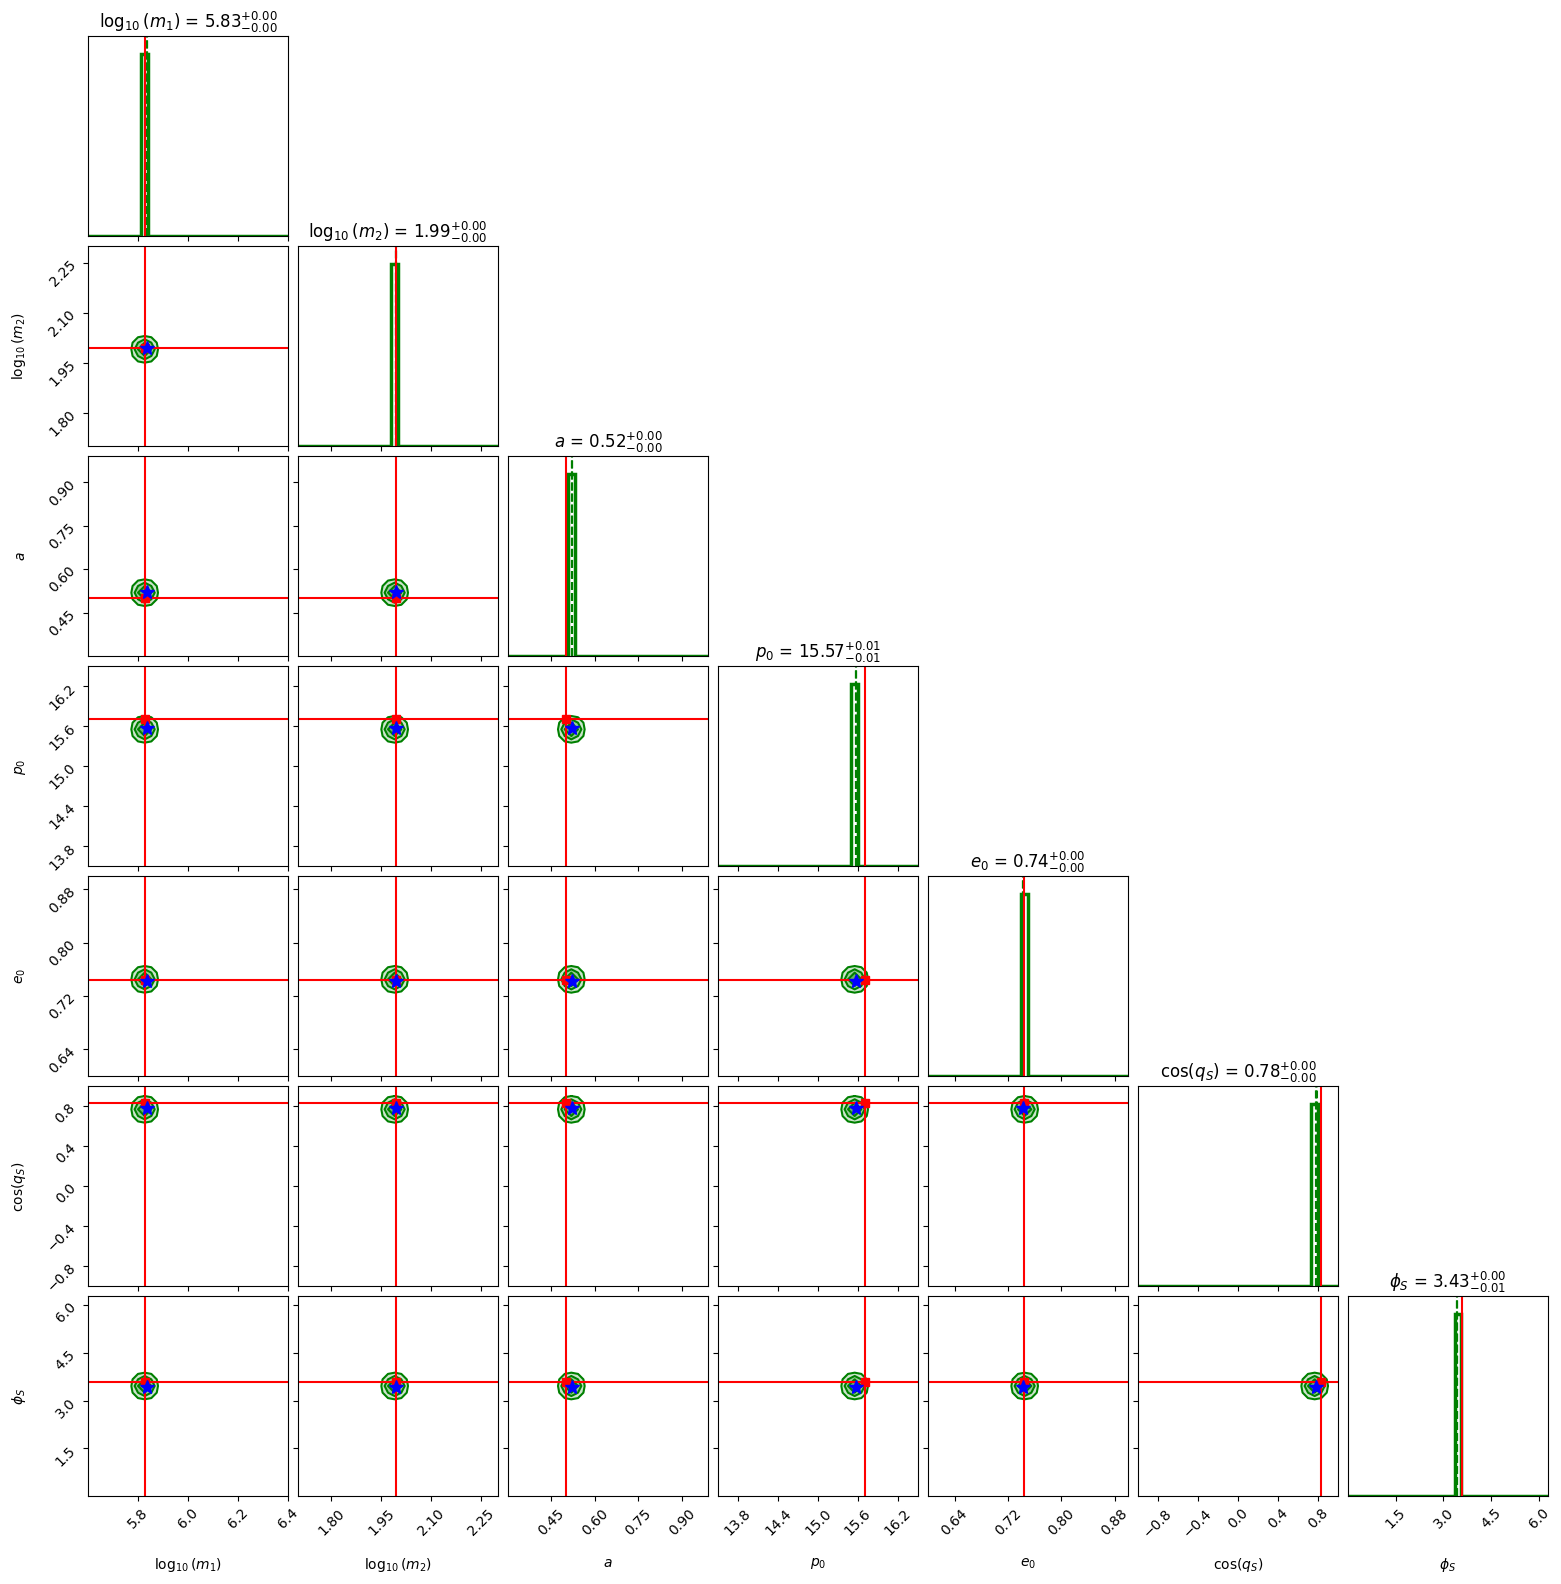

In [12]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

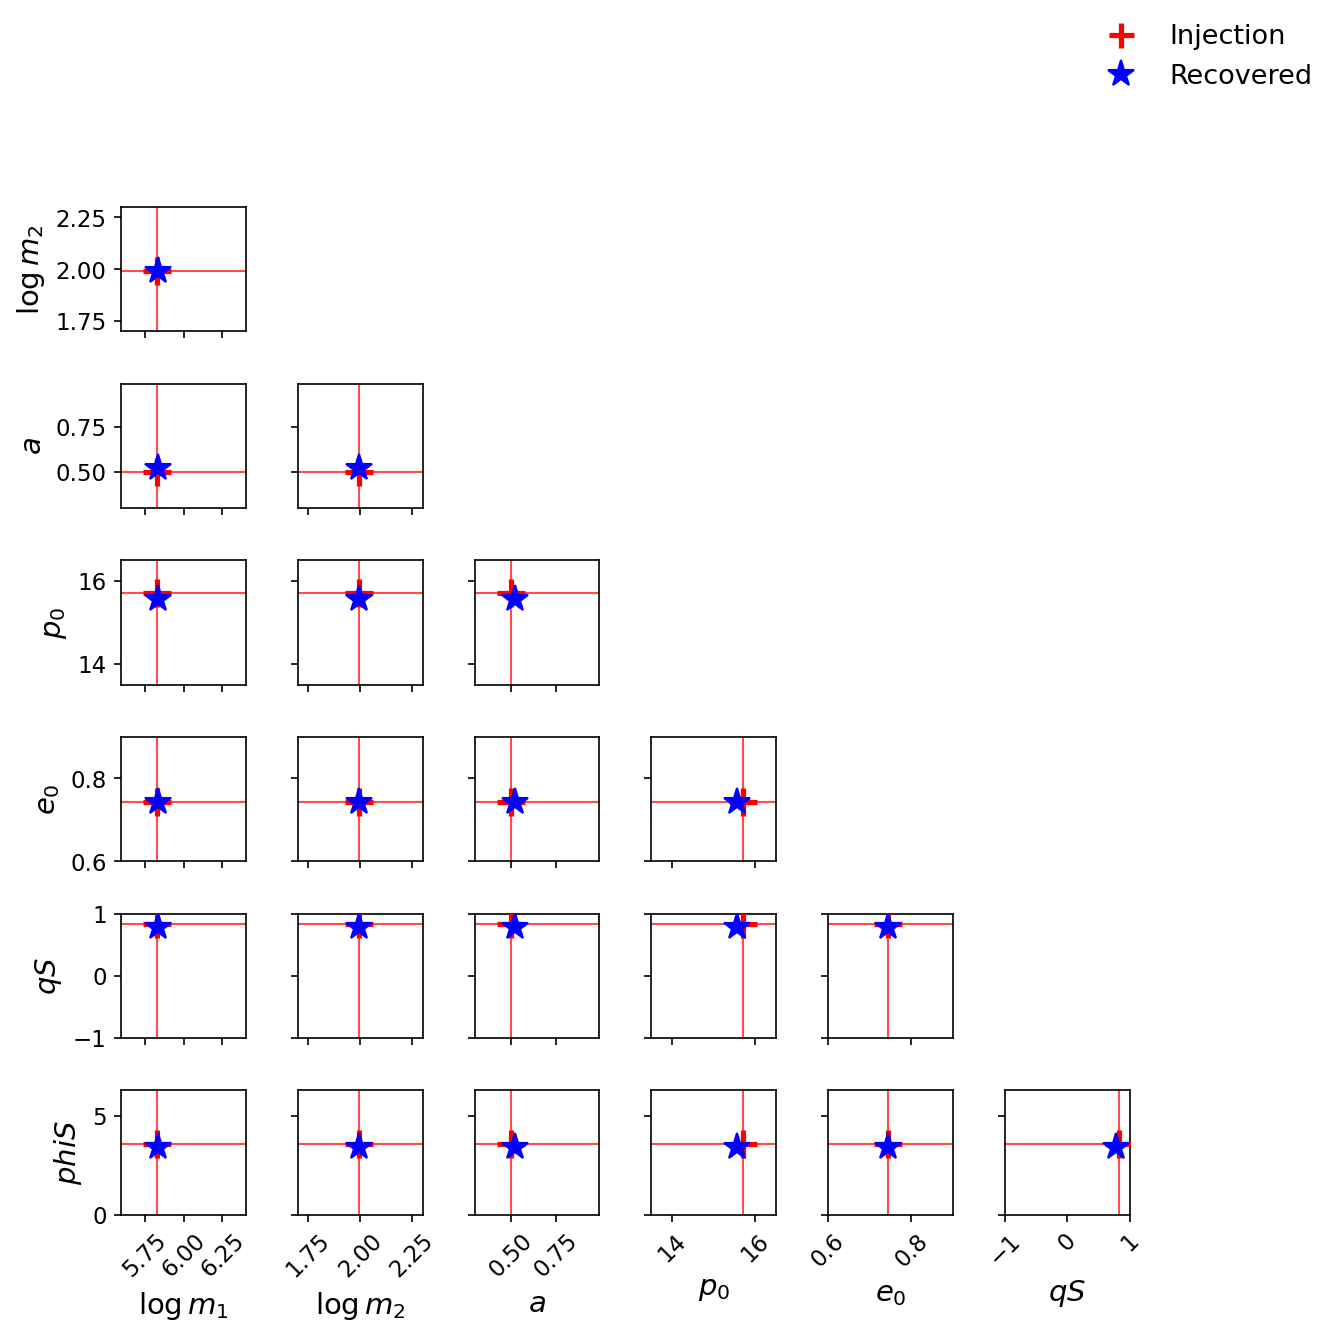

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [14]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.83486482,  1.99418451,  0.52133036, 15.56813091,  0.74317885,
         0.78351432,  3.42344675]])

In [15]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [16]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [17]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


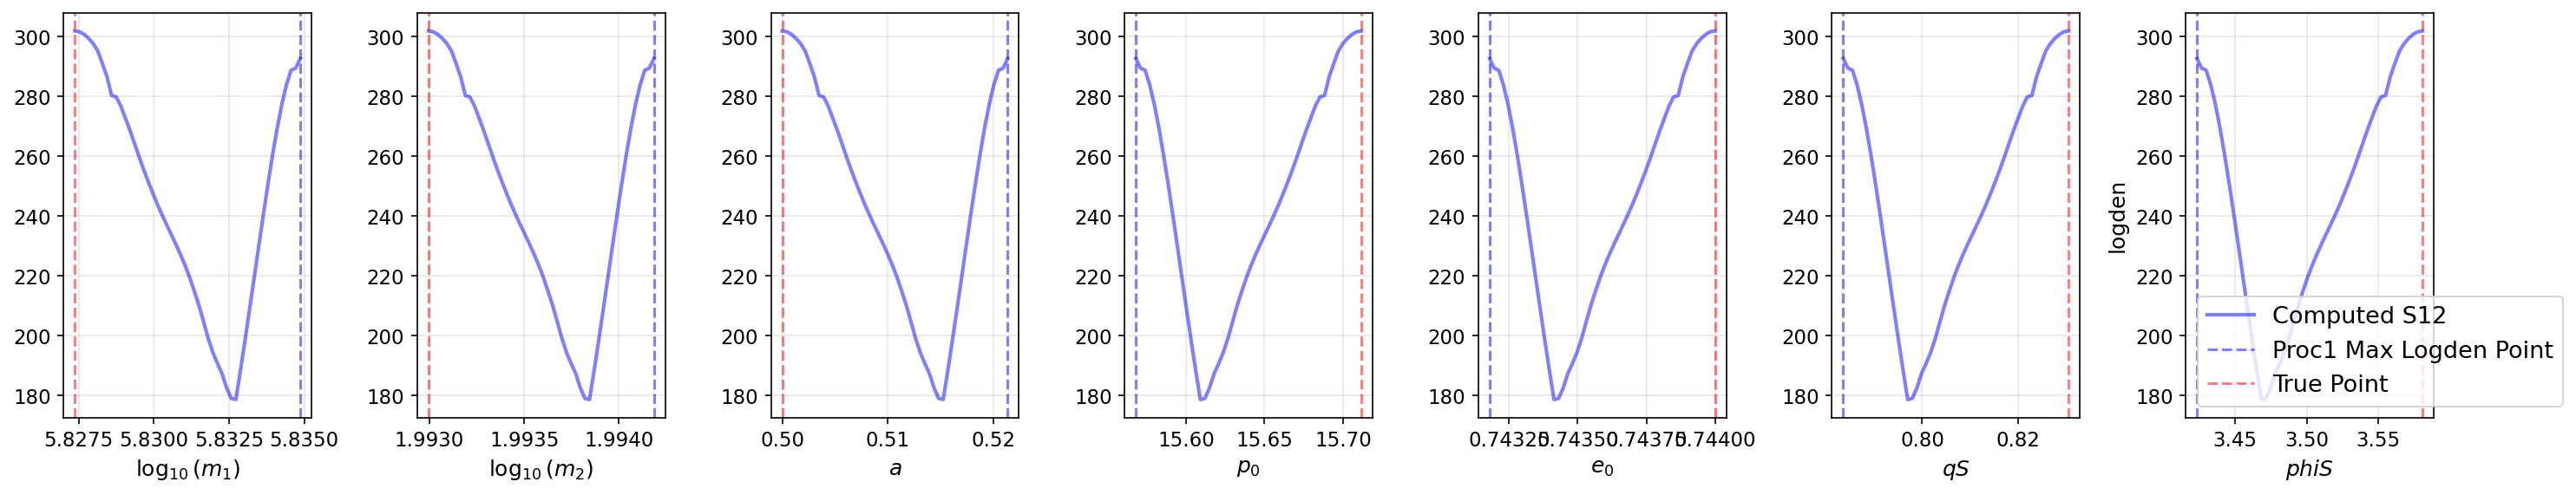

In [18]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [20]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=5.83486  sigma=0.00035  true offset = -21.53 sigma
logm2   : mu=1.99418  sigma=0.00008  true offset = -15.02 sigma
a       : mu=0.52133  sigma=0.00100  true offset = -21.34 sigma
p0      : mu=15.56813  sigma=0.00645  true offset = +22.24 sigma
e0      : mu=0.74318  sigma=0.00004  true offset = +20.07 sigma
cos_qS  : mu=0.78351  sigma=0.00211  true offset = +22.37 sigma
phiS    : mu=3.42345  sigma=0.00720  true offset = +21.86 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 22.37


In [26]:
# Prior bounds (same as paris3_lhs_s6_ext.py / stage1_anneal_s12 prior)
p1_lo = np.array([5.6, 1.7, 0.3, 13.5, 0.6, -1.0, 0.0])
p1_hi = np.array([6.4, 2.3, 0.99, 16.5, 0.9, 1.0, 2 * np.pi])

# N_SIGMA needed to cover the true point (from previous cell), rounded up
N_SIGMA = 30
print(f'N_SIGMA = {N_SIGMA:.0f}')

ellipse_lo = np.clip(mu_center - N_SIGMA * sigma_diag, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA * sigma_diag, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

vol_frac = np.prod(box_width / full_width)
print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 30
logm1   : [5.82442, 5.84531]  width=0.02089  (2.61% of full prior width)
logm2   : [1.99181, 1.99656]  width=0.00475  (0.79% of full prior width)
a       : [0.49134, 0.55132]  width=0.05998  (8.69% of full prior width)
p0      : [15.37450, 15.76176]  width=0.38726  (12.91% of full prior width)
e0      : [0.74195, 0.74441]  width=0.00246  (0.82% of full prior width)
cos_qS  : [0.72035, 0.84668]  width=0.12633  (6.32% of full prior width)
phiS    : [3.20755, 3.63934]  width=0.43180  (6.87% of full prior width)

Box volume fraction of full prior box: 8.241e-11  (log10 = -10.08)


In [24]:

_p1_lo = np.array([5.6, 1.7, 0.3, 13.5, 0.6, -1.0, 0.0])
_p1_hi = np.array([6.4, 2.3, 0.99, 16.5, 0.9, 1.0, 2 * np.pi])

def _stub_prior_transform(u):
    return _p1_lo + (_p1_hi - _p1_lo) * u

def log_density(params):
    raise RuntimeError("stub")

def prior_transform(u):
    return _stub_prior_transform(u)

import __main__
__main__.log_density    = log_density
__main__.prior_transform = prior_transform

stage1_anneal_path = '/scratch/e1498138/paper/ext/emri_g/stage1_anneal_s12_dev/sampler_state.pkl'
print(f'Loading stage1_anneal_s12 sampler from {stage1_anneal_path}...')
sampler_1 = parismc.Sampler.load_state(stage1_anneal_path)

all_pts_u  = sampler_1.searched_points_list[0]
all_logden = sampler_1.searched_log_densities_list[0]
maxld_idx  = np.argmax(all_logden)
mu_center  = _stub_prior_transform(all_pts_u[maxld_idx].reshape(1, -1))[0]
print(f'stage1_anneal_s12 maxld: {all_logden[maxld_idx]:.4f}')
print(f'stage1_anneal_s12 maxld point: {mu_center}')

Loading stage1_anneal_s12 sampler from /scratch/e1498138/paper/ext/emri_g/stage1_anneal_s12_dev/sampler_state.pkl...
stage1_anneal_s12 maxld: 2927.2366
stage1_anneal_s12 maxld point: [ 5.83486482  1.99418451  0.52133036 15.56813091  0.74317885  0.78351432
  3.42344675]


In [25]:
samples_p1, weights_p1 = sampler_1.get_samples_with_weights(flatten=True)
weights_p1 = weights_p1 / weights_p1.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples_p1), size=50_000, replace=True, p=weights_p1)
cov_posterior = np.cov(samples_p1[idx_rs].T)
print('stage1_anneal_s12 posterior 1-sigma (diag):', np.sqrt(np.diag(cov_posterior)))


stage1_anneal_s12 posterior 1-sigma (diag): [3.48173520e-04 7.91679414e-05 9.99705828e-04 6.45436402e-03
 4.09167968e-05 2.10549342e-03 7.19659666e-03]
